In [12]:
import numpy as np
import pymcel as pym 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

Vamos a definir el sistema que se compone por listas de diccionarios en unidades canonicas

In [47]:
sistema =[
    dict(m=0.3, r=[0, 0, 0], v=[0, 0, 0]),
    dict(m=0.5, r=[1, 0, 0], v=[0, -1, 0]),
]

[0.3, 0.5]

Solucion con pymcel

In [51]:
T = 20
ts = np.linspace(0, T, 100)
rs, vs, rcms, vcms, _ = pym.ncuerpos_solucion(sistema, ts)

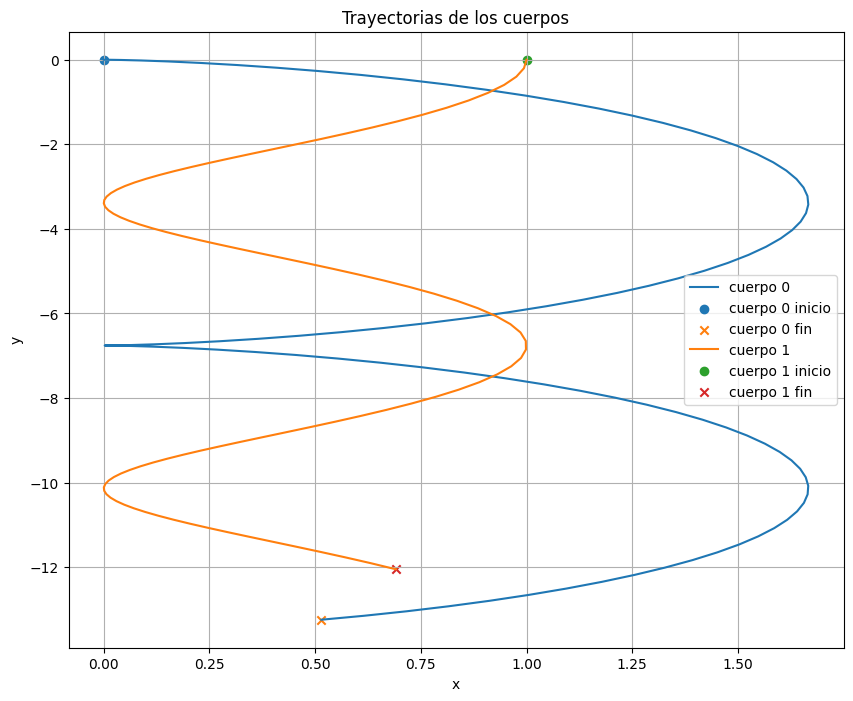

In [49]:
plt.figure(figsize=(10, 8))

for i in range(len(sistema)):
    plt.plot(rs[i, :, 0], rs[i, :, 1], label=f'cuerpo {i}')
    plt.scatter(rs[i, 0, 0], rs[i, 0, 1], marker='o', label=f'cuerpo {i} inicio')
    plt.scatter(rs[i, -1, 0], rs[i, -1, 1], marker='x', label=f'cuerpo {i} fin')

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.show()


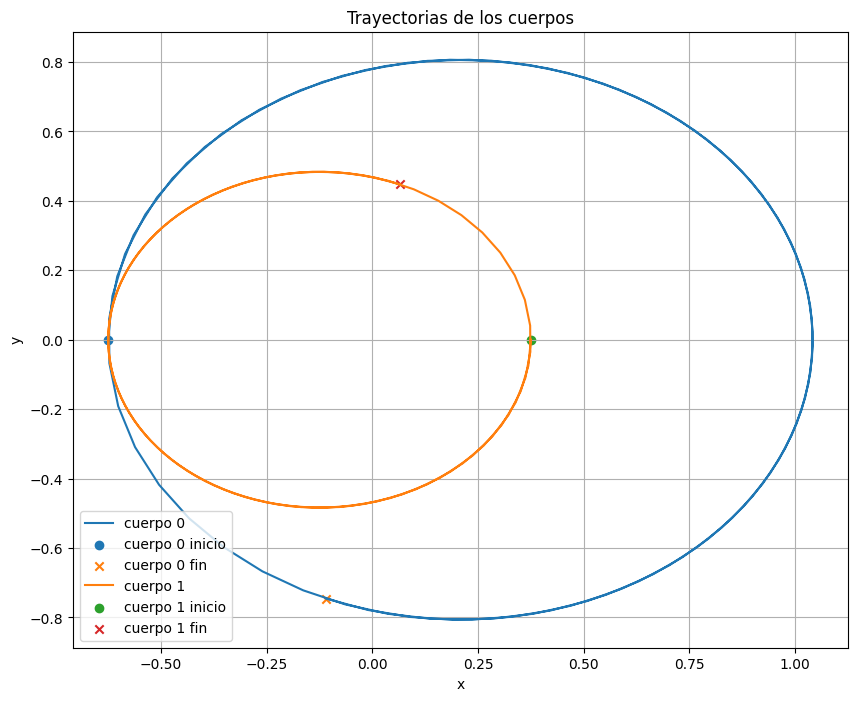

In [52]:
plt.figure(figsize=(10, 8))

for i in range(len(sistema)):
    plt.plot(rcms[i, :, 0], rcms[i, :, 1], label=f'cuerpo {i}')
    plt.scatter(rcms[i, 0, 0], rcms[i, 0, 1], marker='o', label=f'cuerpo {i} inicio')
    plt.scatter(rcms[i, -1, 0], rcms[i, -1, 1], marker='x', label=f'cuerpo {i} fin')

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.show()


In [53]:
# Gráfico 3D de las órbitas con respecto al centro de masa
fig = go.Figure()

# Añadir las trayectorias de cada cuerpo
for i in range(len(sistema)):
    # Trayectoria
    fig.add_trace(go.Scatter3d(
        x=rcms[i, :, 0],
        y=rcms[i, :, 1],
        z=rcms[i, :, 2],
        mode='lines',
        name=f'Cuerpo {i+1} (m={sistema[i]["m"]})',
        line=dict(width=3)
    ))
    
    # Punto inicial
    fig.add_trace(go.Scatter3d(
        x=[rcms[i, 0, 0]],
        y=[rcms[i, 0, 1]],
        z=[rcms[i, 0, 2]],
        mode='markers',
        name=f'Inicio {i+1}',
        marker=dict(size=8, symbol='circle')
    ))
    
    # Punto final
    fig.add_trace(go.Scatter3d(
        x=[rcms[i, -1, 0]],
        y=[rcms[i, -1, 1]],
        z=[rcms[i, -1, 2]],
        mode='markers',
        name=f'Fin {i+1}',
        marker=dict(size=8, symbol='x')
    ))

# Centro de masa (origen)
fig.add_trace(go.Scatter3d(
    x=[0],
    y=[0],
    z=[0],
    mode='markers',
    name='Centro de Masa',
    marker=dict(size=10, color='black', symbol='diamond')
))

fig.update_layout(
    title='Órbitas con respecto al Centro de Masa',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube'
    ),
    width=900,
    height=700
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Cuadraturas.... 




### Momentum lineal total $\vec{P}_{tot} = \sum_{i= 0}^N m_i \dot{\vec{r}}_i$


In [56]:
ms = [cuerpo['m'] for cuerpo in sistema]
ms

[0.3, 0.5]

In [59]:
P_cuerpos = np.array(ms)[:, np.newaxis, np.newaxis] * vs
P_cuerpos

array([[[ 0.        ,  0.        ,  0.        ],
        [ 0.03001708, -0.0030341 ,  0.        ],
        [ 0.05837883, -0.01182652,  0.        ],
        [ 0.08370754, -0.02552893,  0.        ],
        [ 0.10508262, -0.04295962,  0.        ],
        [ 0.12208067, -0.06284318,  0.        ],
        [ 0.13470174, -0.08400422,  0.        ],
        [ 0.14324041, -0.10547823,  0.        ],
        [ 0.14815491, -0.12654526,  0.        ],
        [ 0.14996398, -0.1467127 ,  0.        ],
        [ 0.14917884, -0.16567403,  0.        ],
        [ 0.14626557, -0.18326233,  0.        ],
        [ 0.14162903, -0.19940869,  0.        ],
        [ 0.13560991, -0.21410892,  0.        ],
        [ 0.12848896, -0.22739888,  0.        ],
        [ 0.12049427, -0.23933717,  0.        ],
        [ 0.1118094 , -0.24999328,  0.        ],
        [ 0.10258118, -0.25943993,  0.        ],
        [ 0.09292661, -0.26774822,  0.        ],
        [ 0.08293873, -0.27498466,  0.        ],
        [ 0.07269157

In [62]:
P_tot = sum(P_cuerpos)
P_tot

array([[ 0.00000000e+00, -5.00000000e-01,  0.00000000e+00],
       [ 3.46944695e-18, -5.00000000e-01,  0.00000000e+00],
       [ 1.38777878e-17, -5.00000000e-01,  0.00000000e+00],
       [ 1.38777878e-17, -5.00000000e-01,  0.00000000e+00],
       [ 1.38777878e-17, -5.00000000e-01,  0.00000000e+00],
       [ 1.38777878e-17, -5.00000000e-01,  0.00000000e+00],
       [ 0.00000000e+00, -5.00000000e-01,  0.00000000e+00],
       [-2.77555756e-17, -5.00000000e-01,  0.00000000e+00],
       [-2.77555756e-17, -5.00000000e-01,  0.00000000e+00],
       [-2.77555756e-17, -5.00000000e-01,  0.00000000e+00],
       [-5.55111512e-17, -5.00000000e-01,  0.00000000e+00],
       [-2.77555756e-17, -5.00000000e-01,  0.00000000e+00],
       [-8.32667268e-17, -5.00000000e-01,  0.00000000e+00],
       [-5.55111512e-17, -5.00000000e-01,  0.00000000e+00],
       [-8.32667268e-17, -5.00000000e-01,  0.00000000e+00],
       [-4.16333634e-17, -5.00000000e-01,  0.00000000e+00],
       [-5.55111512e-17, -5.00000000e-01

### Momentum angular total del sistema $\sum_{i=0}^N \vec{r}_i \times \dot{\vec{r}}_i$

In [66]:
# Momentum angular de cada cuerpo: L_i(t) = r_i(t) x v_i(t)
L_cuerpos = np.array(ms)[:, np.newaxis, np.newaxis] * np.cross(rs, vs)

# Momentum angular total del sistema en cada instante: L_tot(t) = sum_i L_i(t)
L_tot = np.sum(L_cuerpos, axis=0)

L_tot

array([[ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.50000001],
       [ 0.        ,  0.        , -0.50000001],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.5       ],
       [ 0.        ,  0.        , -0.49999999],
       [ 0.        ,  0.        , -0.49999999],
       [ 0.        ,  0.        , -0.49999999],
       [ 0.        ,  0.        , -0.49999998],
       [ 0.        ,  0.        , -0.49999998],
       [ 0.        ,  0.        , -0.49999998],
       [ 0.        ,  0.        , -0.49999998],
       [ 0.        ,  0.        , -0.499